# Análisis del Dataset Auto MPG
**Objetivo:** Utilizar las librerías numpy, pandas y matplotlib para procesar, limpiar y analizar un conjunto de datos de vehículos.

## Parte 1: Carga y Limpieza de Datos
En esta sección se cargará el dataset, se revisarán los tipos de datos y se limpiarán los valores nulos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Cargar el Dataset
Se carga el dataset Auto MPG desde una URL usando Pandas.

In [2]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url)

In [3]:
print(df.head())
print(df.dtypes)

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin           object
name             object
dtype: object


In [4]:
print(df['horsepower'].isnull().sum())

6


### Limpieza de Datos
Se identifican valores nulos en la columna horsepower y se reemplazan con la mediana.

In [5]:
mediana_hp = np.nanmedian(df['horsepower'])
df['horsepower'].fillna(mediana_hp, inplace=True)

/tmp/ipykernel_502/1191268353.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horsepower'].fillna(mediana_hp, inplace=True)


In [6]:
df['relacion_peso_potencia'] = df['weight'] / df['horsepower']
print(df.head())

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  relacion_peso_potencia  
0          70    usa  chevrolet chevelle malibu               26.953846  
1          70    usa          buick skylark 320               22.381818  
2          70    usa         plymouth satellite               22.906667  
3          70    usa              amc rebel sst               22.886667  
4          70    usa                ford torino               24.635714  


## Parte 2: Visualización de Datos
En esta sección se crearán diferentes gráficas utilizando Matplotlib.

### Histograma de Aceleración
Esta gráfica muestra la distribución de la aceleración de los vehículos.

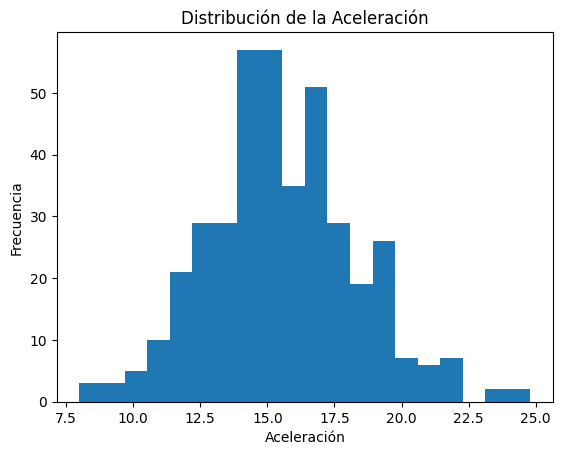

In [7]:
plt.figure()
plt.hist(df['acceleration'], bins=20)
plt.title('Distribución de la Aceleración')
plt.xlabel('Aceleración')
plt.ylabel('Frecuencia')
plt.show()

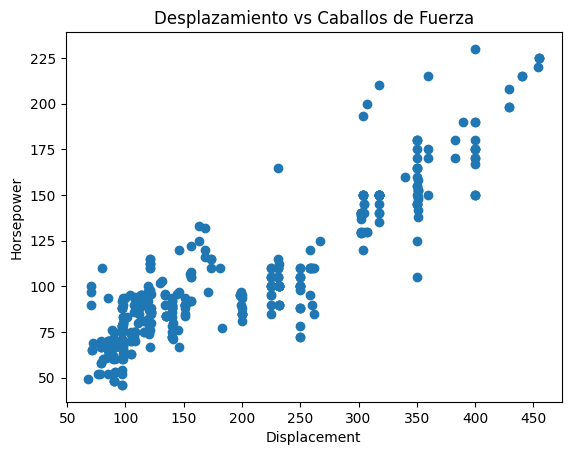

In [8]:
plt.figure()
plt.scatter(df['displacement'], df['horsepower'])
plt.title('Desplazamiento vs Caballos de Fuerza')
plt.xlabel('Displacement')
plt.ylabel('Horsepower')
plt.show()

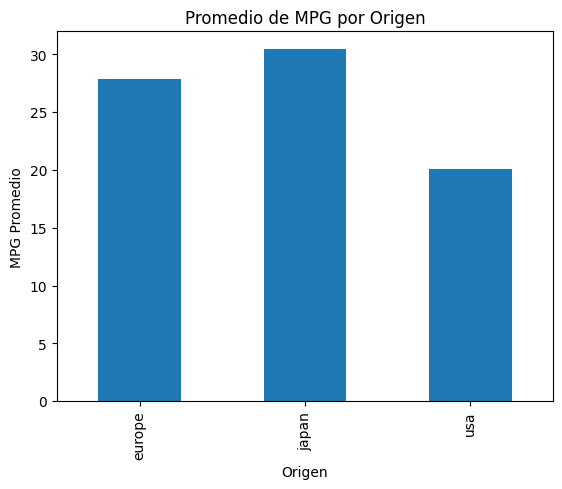

In [9]:
mpg_promedio = df.groupby('origin')['mpg'].mean()

plt.figure()
mpg_promedio.plot(kind='bar')
plt.title('Promedio de MPG por Origen')
plt.xlabel('Origen')
plt.ylabel('MPG Promedio')
plt.show()